In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

[3.25324285 8.53119913] [  4.20973311 -14.98270561]
20.431552144029077 21.374919340008955 8.777426388879363


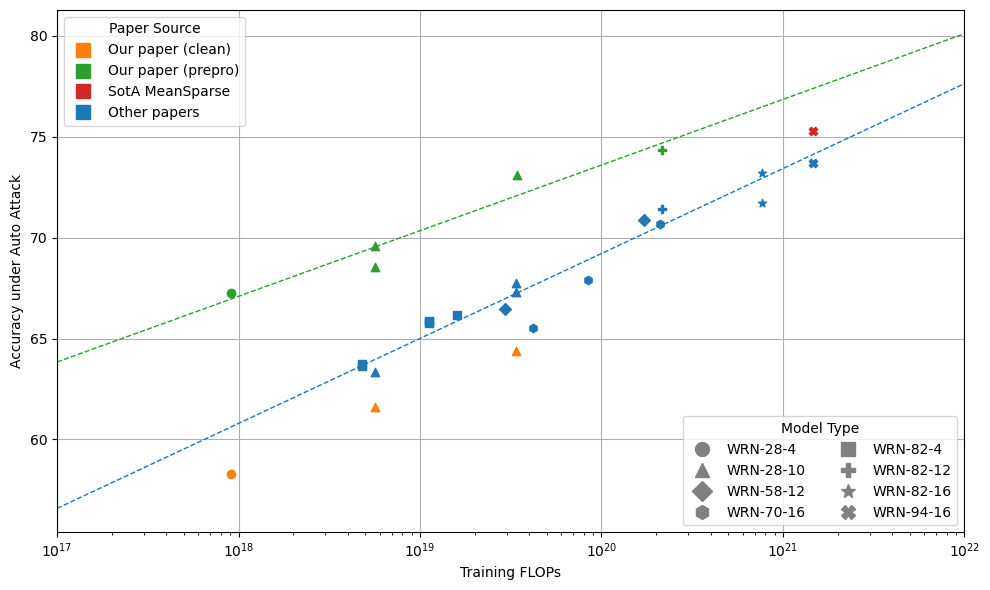

In [3]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from scipy import optimize

fig, ax = plt.subplots(figsize=(10, 6))

# Data for our models
wrn_28_4_clean_FLOPs = [9.126e17]
wrn_28_4_clean_AA_acc = [58.28]

wrn_28_4_fil_FLOPs = [9.145e17]
wrn_28_4_fil_AA_acc = [67.24]

wrn_28_10_clean_FLOPs = [5.665e18, 5.665e18*6]
wrn_28_10_clean_AA_acc = [61.6, 64.4]

wrn_28_10_fil_FLOPs = [5.673e18, 5.678e18, 3.407e19, ]
wrn_28_10_fil_AA_acc = [68.56, 69.6, 73.08, ]

in_wrn_28_10_fil_FLOPs = [3.407e19/24*20, 3.407e19/24*16]
in_wrn_28_10_fil_AA_acc = [71.06, 69.28]

wrn_82_12_fil_FLOPs = [2.149e+20] 
wrn_82_12_fil_AA_acc = [74.32]

# Data for other papers
wrn_28_10_FLOPs = [3.399e19, 3.399e19, 5.665e18]
wrn_28_10_AA_acc = [67.31, 67.75, 63.35]

wrn_58_12_FLOPs = [1.71714816e+20, 2.9387764224e+19]
wrn_58_12_AA_acc = [70.85, 66.48]

wrn_70_16_FLOPs = [4.19e19, 8.38e19, 2.09e20]
wrn_70_16_AA_acc = [65.54, 67.92, 70.69]

wrn_82_4_FLOPs = [1.5980544e+19, 1.11863808e+19, 1.11863808e+19, 1.11863808e+19, 4.7941632e+18, 4.7941632e+18]
wrn_82_4_AA_acc = [66.15, 65.77, 65.83, 65.86, 63.75, 63.65]

wrn_82_12_FLOPs = [2.14866432e+20]
wrn_82_12_AA_acc = [71.41]

wrn_82_16_FLOPs = [7.63665408e20, 7.63665408e20]
wrn_82_16_AA_acc = [71.7, 73.21]

wrn_94_16_FLOPs = [1.47322368e21]
wrn_94_16_AA_acc = [73.71]

mean_spars_FLOPs = [1.47322368e21]
mean_spars_AA_acc = [75.28]

# Define colors and markers for different model types
us_color = 'tab:orange'     # Our paper (clean)
filter_color = 'tab:green'  # Our paper (filter)
other_color = 'tab:blue'    # Other papers
SotA_color = 'tab:red'

wrn_28_4_marker = 'o'       # WRN-28-4
wrn_28_10_marker = '^'      # WRN-28-10
wrn_58_12_marker = 'D'      # WRN-58-12
wrn_70_16_marker = 'h'
wrn_82_4_marker = 's'       # WRN-82-4
wrn_82_12_marker = 'P'      # WRN-82-12
wrn_82_16_marker = '*'      # WRN-82-16
wrn_94_16_marker = 'X'      # WRN-94-16

# Scatter plots for our models
# WRN-28-4 (clean, our paper)
ax.scatter(wrn_28_4_clean_FLOPs, wrn_28_4_clean_AA_acc, c=us_color, marker=wrn_28_4_marker, label='_nolegend_')

# WRN-28-4 (filtered, our paper)
ax.scatter(wrn_28_4_fil_FLOPs, wrn_28_4_fil_AA_acc, c=filter_color, marker=wrn_28_4_marker, label='_nolegend_')

# WRN-28-10 (clean, our paper)
ax.scatter(wrn_28_10_clean_FLOPs, wrn_28_10_clean_AA_acc, c=us_color, marker=wrn_28_10_marker, label='_nolegend_')

# WRN-28-10 (filtered, our paper)
ax.scatter(wrn_28_10_fil_FLOPs, wrn_28_10_fil_AA_acc, c=filter_color, marker=wrn_28_10_marker, label='_nolegend_')

# WRN-82-12 (filtered, our paper)
ax.scatter(wrn_82_12_fil_FLOPs, wrn_82_12_fil_AA_acc, c=filter_color, marker=wrn_82_12_marker, label='_nolegend_')

# Scatter plots for other papers
# WRN-28-10 (other papers)
ax.scatter(wrn_28_10_FLOPs, wrn_28_10_AA_acc, c=other_color, marker=wrn_28_10_marker, label='_nolegend_')

# WRN-58-12
ax.scatter(wrn_58_12_FLOPs, wrn_58_12_AA_acc, c=other_color, marker=wrn_58_12_marker, label='_nolegend_')

# WRN-70-16
ax.scatter(wrn_70_16_FLOPs, wrn_70_16_AA_acc, c=other_color, marker=wrn_70_16_marker, label='_nolegend_')

# WRN-82-4
ax.scatter(wrn_82_4_FLOPs, wrn_82_4_AA_acc, c=other_color, marker=wrn_82_4_marker, label='_nolegend_')

# WRN-82-12
ax.scatter(wrn_82_12_FLOPs, wrn_82_12_AA_acc, c=other_color, marker=wrn_82_12_marker, label='_nolegend_')

# WRN-82-16
ax.scatter(wrn_82_16_FLOPs, wrn_82_16_AA_acc, c=other_color, marker=wrn_82_16_marker, label='_nolegend_')

# WRN-94-16
ax.scatter(wrn_94_16_FLOPs, wrn_94_16_AA_acc, c=other_color, marker=wrn_94_16_marker, label='_nolegend_')

# MeanSparsw
ax.scatter(mean_spars_FLOPs, mean_spars_AA_acc, c=SotA_color, marker=wrn_94_16_marker, label='_nolegend_')

# Combine all filtered (green) data for fitting
filtered_FLOPs = wrn_28_4_fil_FLOPs + wrn_28_10_fil_FLOPs + wrn_82_12_fil_FLOPs
filtered_AA_acc = wrn_28_4_fil_AA_acc + wrn_28_10_fil_AA_acc + wrn_82_12_fil_AA_acc

# Combine all other papers (blue) data for fitting
other_FLOPs = wrn_28_10_FLOPs + wrn_58_12_FLOPs + wrn_70_16_FLOPs + wrn_82_4_FLOPs + wrn_82_12_FLOPs + wrn_82_16_FLOPs + wrn_94_16_FLOPs + mean_spars_FLOPs
other_AA_acc = wrn_28_10_AA_acc + wrn_58_12_AA_acc + wrn_70_16_AA_acc + wrn_82_4_AA_acc + wrn_82_12_AA_acc + wrn_82_16_AA_acc + wrn_94_16_AA_acc + mean_spars_AA_acc

# Fit curves
filtered_log_x = np.log10(filtered_FLOPs)
other_log_x = np.log10(other_FLOPs)

# For filtered data (green)
filtered_params, _ = optimize.curve_fit(lambda x, a, b: a * x + b, filtered_log_x, filtered_AA_acc)
a_filtered, b_filtered = filtered_params

# For other papers data (blue)
other_params, _ = optimize.curve_fit(lambda x, a, b: a * x + b, other_log_x, other_AA_acc)
a_other, b_other = other_params

print(filtered_params, other_params)

# Generate points for the fitted curves
x_range = np.logspace(17, 22, 100)
log_x_range = np.log10(x_range)

# Calculate fitted values
y_filtered = a_filtered * log_x_range + b_filtered
y_other = a_other * log_x_range + b_other

ninty_filterd = (75.-b_filtered)/a_filtered
ninty_other = (75.-b_other)/a_other

print(ninty_filterd, ninty_other, 10**(ninty_other-ninty_filterd))

# Plot the fitted curves
ax.plot(x_range, y_filtered, color=filter_color, linestyle='--', linewidth=1)
ax.plot(x_range, y_other, color=other_color, linestyle='--', linewidth=1)

# Set x-axis to logarithmic scale
ax.set_xscale('log')
ax.set_xlim(1e17, 1e22)
ax.grid(True)

# Add labels
plt.xlabel('Training FLOPs')
plt.ylabel('Accuracy under Auto Attack')

# Create custom legend handles
# Color legend (source of paper)
our_paper_handle = mlines.Line2D([], [], color=us_color, marker='s', linestyle='None', markersize=10, label='Our paper (clean)')
filter_handle = mlines.Line2D([], [], color=filter_color, marker='s', linestyle='None', markersize=10, label='Our paper (prepro)')
other_paper_handle = mlines.Line2D([], [], color=other_color, marker='s', linestyle='None', markersize=10, label='Other papers')
SotA_handle = mlines.Line2D([], [], color=SotA_color, marker='s', linestyle='None', markersize=10, label='SotA MeanSparse')

# Model type legend
wrn_28_4_handle = mlines.Line2D([], [], color='gray', marker=wrn_28_4_marker, linestyle='None', markersize=10, label='WRN-28-4')
wrn_28_10_handle = mlines.Line2D([], [], color='gray', marker=wrn_28_10_marker, linestyle='None', markersize=10, label='WRN-28-10')
wrn_58_12_handle = mlines.Line2D([], [], color='gray', marker=wrn_58_12_marker, linestyle='None', markersize=10, label='WRN-58-12')
wrn_70_16_handle = mlines.Line2D([], [], color='gray', marker=wrn_70_16_marker, linestyle='None', markersize=10, label='WRN-70-16')
wrn_82_4_handle = mlines.Line2D([], [], color='gray', marker=wrn_82_4_marker, linestyle='None', markersize=10, label='WRN-82-4')
wrn_82_12_handle = mlines.Line2D([], [], color='gray', marker=wrn_82_12_marker, linestyle='None', markersize=10, label='WRN-82-12')
wrn_82_16_handle = mlines.Line2D([], [], color='gray', marker=wrn_82_16_marker, linestyle='None', markersize=10, label='WRN-82-16')
wrn_94_16_handle = mlines.Line2D([], [], color='gray', marker=wrn_94_16_marker, linestyle='None', markersize=10, label='WRN-94-16')

# Create the first legend for paper sources including fitted curves
first_legend = ax.legend(handles=[our_paper_handle, filter_handle, SotA_handle, other_paper_handle], 
                         loc='upper left', title='Paper Source')

# Add the first legend manually to the plot
ax.add_artist(first_legend)

# Create the second legend for model types
second_legend = ax.legend(handles=[wrn_28_4_handle, wrn_28_10_handle, wrn_58_12_handle, wrn_70_16_handle,
                                   wrn_82_4_handle, wrn_82_12_handle, wrn_82_16_handle, wrn_94_16_handle], 
                          loc='lower right', title='Model Type', ncol=2)  # Using 2 columns for better spacing

plt.tight_layout()
plt.savefig("FLOPs.svg")
plt.show()

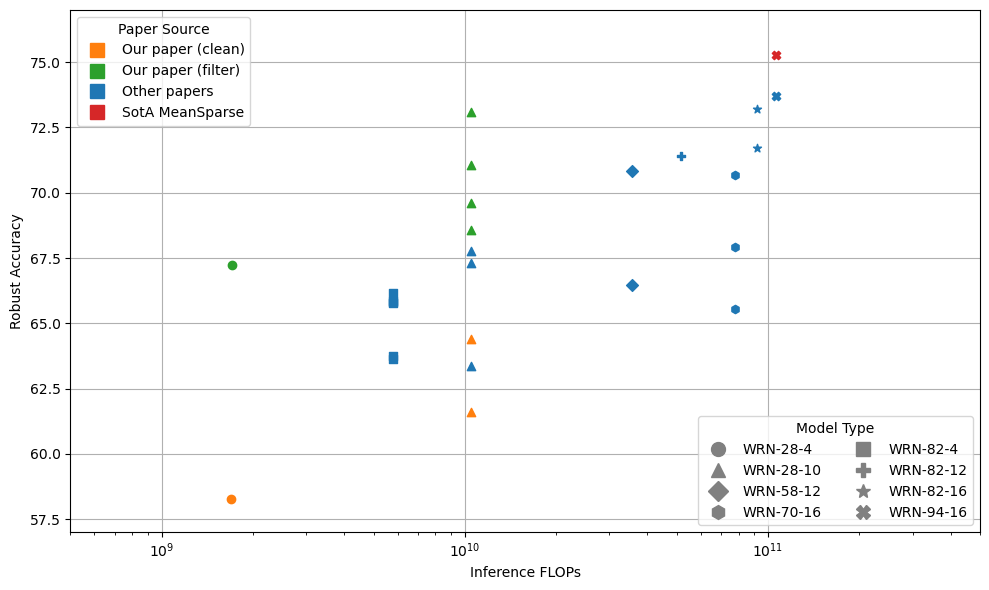

In [16]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# Updated FLOPs data
FLOPs_clean_WRN_28_4 = 1.69e9
FLOPs_clean_WRN_28_10 = 10.49e9
FLOPs_clean_WRN_58_12 = 35.49e9
FLOPs_clean_WRN_70_16 = 77.56e9
FLOPs_clean_WRN_82_4 = 5.78e9
FLOPs_clean_WRN_82_12 = 51.81e9
FLOPs_clean_WRN_82_16 = 92.07e9
FLOPs_clean_WRN_94_16 = 106.57e9  

filter_FLOPs = 15.747e6

# Calculate total FLOPs for filtered models
FLOPs_filtered_WRN_28_4 = FLOPs_clean_WRN_28_4 + filter_FLOPs
FLOPs_filtered_WRN_28_10 = FLOPs_clean_WRN_28_10 + filter_FLOPs
FLOPs_filtered_WRN_28_10_80 = FLOPs_clean_WRN_28_10 + filter_FLOPs/50*80
FLOPs_filtered_WRN_58_12 = FLOPs_clean_WRN_58_12 + filter_FLOPs
FLOPs_filtered_WRN_82_4 = FLOPs_clean_WRN_82_4 + filter_FLOPs
FLOPs_filtered_WRN_82_12 = FLOPs_clean_WRN_82_12 + filter_FLOPs
FLOPs_filtered_WRN_82_16 = FLOPs_clean_WRN_82_16 + filter_FLOPs
FLOPs_filtered_WRN_94_16 = FLOPs_clean_WRN_94_16 + filter_FLOPs

# Our data with corrected FLOPs
wrn_28_4_clean_FLOPs = [FLOPs_clean_WRN_28_4]

wrn_28_10_clean_FLOPs = [FLOPs_clean_WRN_28_10, FLOPs_clean_WRN_28_10]

wrn_28_10_fil_FLOPs = [FLOPs_filtered_WRN_28_10,FLOPs_filtered_WRN_28_10_80,FLOPs_filtered_WRN_28_10_80,FLOPs_filtered_WRN_28_10_80]


wrn_28_10_FLOPs = [FLOPs_clean_WRN_28_10, FLOPs_clean_WRN_28_10, FLOPs_clean_WRN_28_10]

wrn_58_12_FLOPs = [FLOPs_clean_WRN_58_12, FLOPs_clean_WRN_58_12]

wrn_70_16_FLOPs = [FLOPs_clean_WRN_70_16,FLOPs_clean_WRN_70_16,FLOPs_clean_WRN_70_16]

wrn_82_4_FLOPs = [FLOPs_clean_WRN_82_4, FLOPs_clean_WRN_82_4, FLOPs_clean_WRN_82_4, 
                  FLOPs_clean_WRN_82_4, FLOPs_clean_WRN_82_4, FLOPs_clean_WRN_82_4]

wrn_82_12_FLOPs = [FLOPs_clean_WRN_82_12]

wrn_82_16_FLOPs = [FLOPs_clean_WRN_82_16, FLOPs_clean_WRN_82_16]

wrn_94_16_FLOPs = [FLOPs_clean_WRN_94_16]

mean_spars_FLOPs = [FLOPs_clean_WRN_94_16]


# Scatter plots
# WRN-28-4 (clean, our paper)
ax.scatter(wrn_28_4_clean_FLOPs, wrn_28_4_clean_AA_acc, c=us_color, marker=wrn_28_4_marker, label='_nolegend_')

# WRN-28-4 (filter, our paper)
ax.scatter(FLOPs_filtered_WRN_28_4, wrn_28_4_fil_AA_acc, c=filter_color, marker=wrn_28_4_marker, label='_nolegend_')

# WRN-28-10 (clean, our paper)
ax.scatter(wrn_28_10_clean_FLOPs, wrn_28_10_clean_AA_acc, c=us_color, marker=wrn_28_10_marker, label='_nolegend_')

# WRN-28-10 (filtered, our paper)
ax.scatter(wrn_28_10_fil_FLOPs, wrn_28_10_fil_AA_acc, c=filter_color, marker=wrn_28_10_marker, label='_nolegend_')

# WRN-28-10 (other papers)
ax.scatter(wrn_28_10_FLOPs, wrn_28_10_AA_acc, c=other_color, marker=wrn_28_10_marker, label='_nolegend_')

# WRN-58-12
ax.scatter(wrn_58_12_FLOPs, wrn_58_12_AA_acc, c=other_color, marker=wrn_58_12_marker, label='_nolegend_')

# WRN-70-16
ax.scatter(wrn_70_16_FLOPs, wrn_70_16_AA_acc, c=other_color, marker=wrn_70_16_marker, label='_nolegend_')

# WRN-82-4
ax.scatter(wrn_82_4_FLOPs, wrn_82_4_AA_acc, c=other_color, marker=wrn_82_4_marker, label='_nolegend_')

# WRN-82-12
ax.scatter(wrn_82_12_FLOPs, wrn_82_12_AA_acc, c=other_color, marker=wrn_82_12_marker, label='_nolegend_')

# WRN-82-16
ax.scatter(wrn_82_16_FLOPs, wrn_82_16_AA_acc, c=other_color, marker=wrn_82_16_marker, label='_nolegend_')

# WRN-94-16
ax.scatter(wrn_94_16_FLOPs, wrn_94_16_AA_acc, c=other_color, marker=wrn_94_16_marker, label='_nolegend_')

# MeanSparsw
ax.scatter(mean_spars_FLOPs, mean_spars_AA_acc, c=SotA_color, marker=wrn_94_16_marker, label='_nolegend_')

# Set x-axis to logarithmic scale
ax.set_xscale('log')
ax.set_xlim(5e8, 5e11)  # Adjusted to show only our data points
ax.set_ylim(57, 77) 
ax.grid(True)

# Add labels
plt.xlabel('Inference FLOPs')
plt.ylabel('Robust Accuracy')


# Create the first legend for paper sources
first_legend = ax.legend(handles=[our_paper_handle, filter_handle, other_paper_handle, SotA_handle], 
                         loc='upper left', title='Paper Source')

# Add the first legend manually to the plot
ax.add_artist(first_legend)

# Create the second legend for model types
ax.legend(handles=[wrn_28_4_handle, wrn_28_10_handle, wrn_58_12_handle, wrn_70_16_handle, 
                  wrn_82_4_handle, wrn_82_12_handle, wrn_82_16_handle, wrn_94_16_handle], 
          loc='lower right', title='Model Type', ncol=2)  # Using 2 columns for better spacing

plt.tight_layout()
plt.savefig("FLOPs2.svg")
plt.show()

[3.25324285 8.53119913] [  4.20973311 -14.98270561]
20.431552144029077 21.374919340008955 8.777426388879363


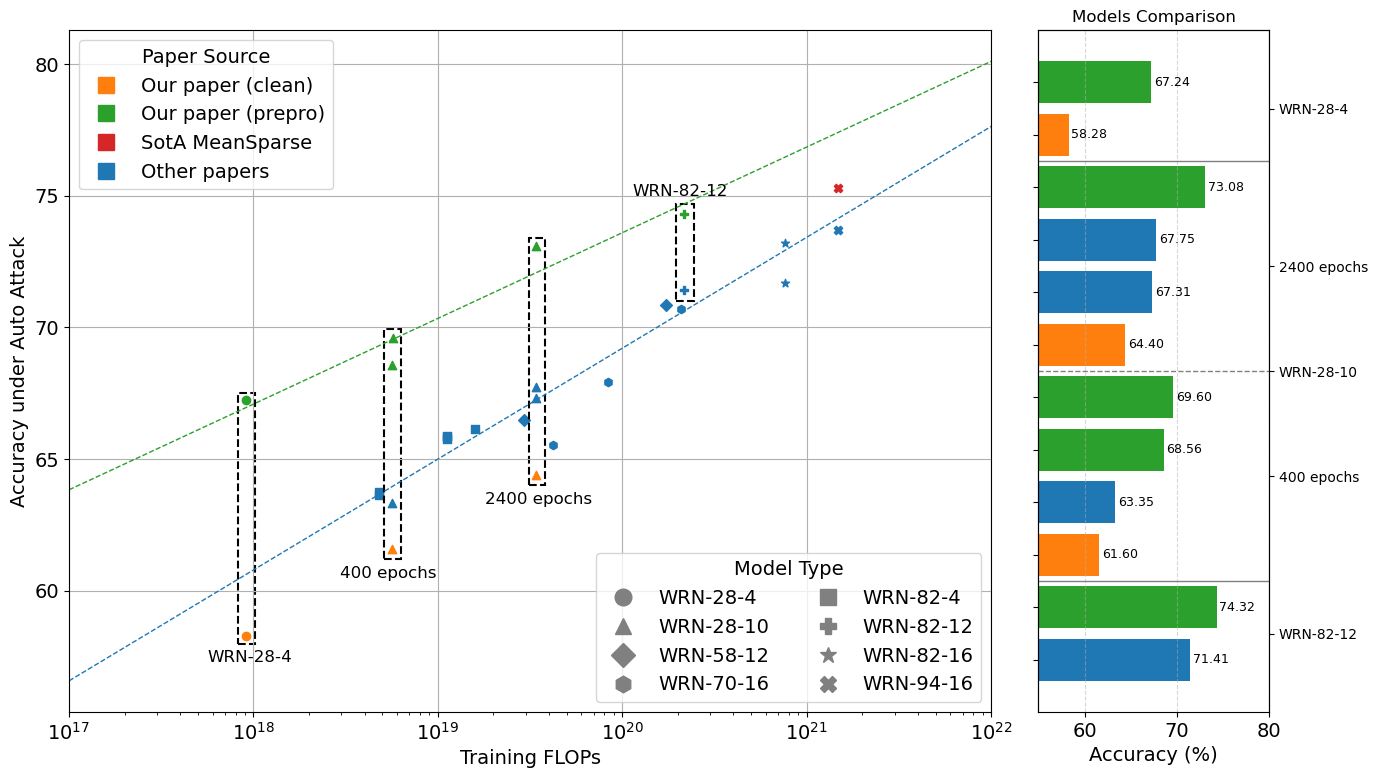

In [38]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from scipy import optimize
import matplotlib.patches as patches

# Create a figure with 2 subplots (main plot and bar plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={'width_ratios': [4, 1]})

plt.rcParams.update({'font.size': 14})

# Data for our models
wrn_28_4_clean_FLOPs = [9.126e17]
wrn_28_4_clean_AA_acc = [58.28]

wrn_28_4_fil_FLOPs = [9.145e17]
wrn_28_4_fil_AA_acc = [67.24]

wrn_28_10_clean_FLOPs = [5.665e18, 5.665e18*6]
wrn_28_10_clean_AA_acc = [61.6, 64.4]

wrn_28_10_fil_FLOPs = [5.673e18, 5.678e18, 3.407e19]
wrn_28_10_fil_AA_acc = [68.56, 69.6, 73.08]

in_wrn_28_10_fil_FLOPs = [3.407e19/24*20, 3.407e19/24*16]
in_wrn_28_10_fil_AA_acc = [71.06, 69.28]

wrn_82_12_fil_FLOPs = [2.149e+20] 
wrn_82_12_fil_AA_acc = [74.32]

# Data for other papers
wrn_28_10_FLOPs = [3.399e19, 3.399e19, 5.665e18]
wrn_28_10_AA_acc = [67.31, 67.75, 63.35]

wrn_58_12_FLOPs = [1.71714816e+20, 2.9387764224e+19]
wrn_58_12_AA_acc = [70.85, 66.48]

wrn_70_16_FLOPs = [4.19e19, 8.38e19, 2.09e20]
wrn_70_16_AA_acc = [65.54, 67.92, 70.69]

wrn_82_4_FLOPs = [1.5980544e+19, 1.11863808e+19, 1.11863808e+19, 1.11863808e+19, 4.7941632e+18, 4.7941632e+18]
wrn_82_4_AA_acc = [66.15, 65.77, 65.83, 65.86, 63.75, 63.65]

wrn_82_12_FLOPs = [2.14866432e+20]
wrn_82_12_AA_acc = [71.41]

wrn_82_16_FLOPs = [7.63665408e20, 7.63665408e20]
wrn_82_16_AA_acc = [71.7, 73.21]

wrn_94_16_FLOPs = [1.47322368e21]
wrn_94_16_AA_acc = [73.71]

mean_spars_FLOPs = [1.47322368e21]
mean_spars_AA_acc = [75.28]

# Define colors and markers for different model types
us_color = 'tab:orange'     # Our paper (clean)
filter_color = 'tab:green'  # Our paper (filter)
other_color = 'tab:blue'    # Other papers
SotA_color = 'tab:red'

wrn_28_4_marker = 'o'       # WRN-28-4
wrn_28_10_marker = '^'      # WRN-28-10
wrn_58_12_marker = 'D'      # WRN-58-12
wrn_70_16_marker = 'h'
wrn_82_4_marker = 's'       # WRN-82-4
wrn_82_12_marker = 'P'      # WRN-82-12
wrn_82_16_marker = '*'      # WRN-82-16
wrn_94_16_marker = 'X'      # WRN-94-16

# Scatter plots for our models on the first axis (ax1)
# WRN-28-4 (clean, our paper)
ax1.scatter(wrn_28_4_clean_FLOPs, wrn_28_4_clean_AA_acc, c=us_color, marker=wrn_28_4_marker, label='_nolegend_')

# WRN-28-4 (filtered, our paper)
ax1.scatter(wrn_28_4_fil_FLOPs, wrn_28_4_fil_AA_acc, c=filter_color, marker=wrn_28_4_marker, label='_nolegend_')

# WRN-28-10 (clean, our paper)
ax1.scatter(wrn_28_10_clean_FLOPs, wrn_28_10_clean_AA_acc, c=us_color, marker=wrn_28_10_marker, label='_nolegend_')

# WRN-28-10 (filtered, our paper)
ax1.scatter(wrn_28_10_fil_FLOPs, wrn_28_10_fil_AA_acc, c=filter_color, marker=wrn_28_10_marker, label='_nolegend_')

# WRN-82-12 (filtered, our paper)
ax1.scatter(wrn_82_12_fil_FLOPs, wrn_82_12_fil_AA_acc, c=filter_color, marker=wrn_82_12_marker, label='_nolegend_')

# Scatter plots for other papers
# WRN-28-10 (other papers)
ax1.scatter(wrn_28_10_FLOPs, wrn_28_10_AA_acc, c=other_color, marker=wrn_28_10_marker, label='_nolegend_')

# WRN-58-12
ax1.scatter(wrn_58_12_FLOPs, wrn_58_12_AA_acc, c=other_color, marker=wrn_58_12_marker, label='_nolegend_')

# WRN-70-16
ax1.scatter(wrn_70_16_FLOPs, wrn_70_16_AA_acc, c=other_color, marker=wrn_70_16_marker, label='_nolegend_')

# WRN-82-4
ax1.scatter(wrn_82_4_FLOPs, wrn_82_4_AA_acc, c=other_color, marker=wrn_82_4_marker, label='_nolegend_')

# WRN-82-12
ax1.scatter(wrn_82_12_FLOPs, wrn_82_12_AA_acc, c=other_color, marker=wrn_82_12_marker, label='_nolegend_')

# WRN-82-16
ax1.scatter(wrn_82_16_FLOPs, wrn_82_16_AA_acc, c=other_color, marker=wrn_82_16_marker, label='_nolegend_')

# WRN-94-16
ax1.scatter(wrn_94_16_FLOPs, wrn_94_16_AA_acc, c=other_color, marker=wrn_94_16_marker, label='_nolegend_')

# MeanSparsw
ax1.scatter(mean_spars_FLOPs, mean_spars_AA_acc, c=SotA_color, marker=wrn_94_16_marker, label='_nolegend_')

# Combine all filtered (green) data for fitting
filtered_FLOPs = wrn_28_4_fil_FLOPs + wrn_28_10_fil_FLOPs + wrn_82_12_fil_FLOPs
filtered_AA_acc = wrn_28_4_fil_AA_acc + wrn_28_10_fil_AA_acc + wrn_82_12_fil_AA_acc

# Combine all other papers (blue) data for fitting
other_FLOPs = wrn_28_10_FLOPs + wrn_58_12_FLOPs + wrn_70_16_FLOPs + wrn_82_4_FLOPs + wrn_82_12_FLOPs + wrn_82_16_FLOPs + wrn_94_16_FLOPs + mean_spars_FLOPs
other_AA_acc = wrn_28_10_AA_acc + wrn_58_12_AA_acc + wrn_70_16_AA_acc + wrn_82_4_AA_acc + wrn_82_12_AA_acc + wrn_82_16_AA_acc + wrn_94_16_AA_acc + mean_spars_AA_acc

# Fit curves
filtered_log_x = np.log10(filtered_FLOPs)
other_log_x = np.log10(other_FLOPs)

# For filtered data (green)
filtered_params, _ = optimize.curve_fit(lambda x, a, b: a * x + b, filtered_log_x, filtered_AA_acc)
a_filtered, b_filtered = filtered_params

# For other papers data (blue)
other_params, _ = optimize.curve_fit(lambda x, a, b: a * x + b, other_log_x, other_AA_acc)
a_other, b_other = other_params

print(filtered_params, other_params)

# Generate points for the fitted curves
x_range = np.logspace(17, 22, 100)
log_x_range = np.log10(x_range)

# Calculate fitted values
y_filtered = a_filtered * log_x_range + b_filtered
y_other = a_other * log_x_range + b_other

ninty_filterd = (75.-b_filtered)/a_filtered
ninty_other = (75.-b_other)/a_other

print(ninty_filterd, ninty_other, 10**(ninty_other-ninty_filterd))

# Plot the fitted curves on ax1
ax1.plot(x_range, y_filtered, color=filter_color, linestyle='--', linewidth=1)
ax1.plot(x_range, y_other, color=other_color, linestyle='--', linewidth=1)

# Set x-axis to logarithmic scale
ax1.set_xscale('log')
ax1.set_xlim(1e17, 1e22)
ax1.grid(True)

# Add labels to main plot
ax1.set_xlabel('Training FLOPs')
ax1.set_ylabel('Accuracy under Auto Attack')

# Create custom legend handles
# Color legend (source of paper)
our_paper_handle = mlines.Line2D([], [], color=us_color, marker='s', linestyle='None', markersize=12, label='Our paper (clean)')
filter_handle = mlines.Line2D([], [], color=filter_color, marker='s', linestyle='None', markersize=12, label='Our paper (prepro)')
other_paper_handle = mlines.Line2D([], [], color=other_color, marker='s', linestyle='None', markersize=12, label='Other papers')
SotA_handle = mlines.Line2D([], [], color=SotA_color, marker='s', linestyle='None', markersize=12, label='SotA MeanSparse')

# Model type legend
wrn_28_4_handle = mlines.Line2D([], [], color='gray', marker=wrn_28_4_marker, linestyle='None', markersize=12, label='WRN-28-4')
wrn_28_10_handle = mlines.Line2D([], [], color='gray', marker=wrn_28_10_marker, linestyle='None', markersize=12, label='WRN-28-10')
wrn_58_12_handle = mlines.Line2D([], [], color='gray', marker=wrn_58_12_marker, linestyle='None', markersize=12, label='WRN-58-12')
wrn_70_16_handle = mlines.Line2D([], [], color='gray', marker=wrn_70_16_marker, linestyle='None', markersize=12, label='WRN-70-16')
wrn_82_4_handle = mlines.Line2D([], [], color='gray', marker=wrn_82_4_marker, linestyle='None', markersize=12, label='WRN-82-4')
wrn_82_12_handle = mlines.Line2D([], [], color='gray', marker=wrn_82_12_marker, linestyle='None', markersize=12, label='WRN-82-12')
wrn_82_16_handle = mlines.Line2D([], [], color='gray', marker=wrn_82_16_marker, linestyle='None', markersize=12, label='WRN-82-16')
wrn_94_16_handle = mlines.Line2D([], [], color='gray', marker=wrn_94_16_marker, linestyle='None', markersize=12, label='WRN-94-16')

# Create the first legend for paper sources including fitted curves
first_legend = ax1.legend(handles=[our_paper_handle, filter_handle, SotA_handle, other_paper_handle], 
                         loc='upper left', title='Paper Source')

# Add the first legend manually to the plot
ax1.add_artist(first_legend)

# Create the second legend for model types
second_legend = ax1.legend(handles=[wrn_28_4_handle, wrn_28_10_handle, wrn_58_12_handle, wrn_70_16_handle,
                                   wrn_82_4_handle, wrn_82_12_handle, wrn_82_16_handle, wrn_94_16_handle], 
                          loc='lower right', title='Model Type', ncol=2)  # Using 2 columns for better spacing

# Box around WRN-28-10 (400 epochs)
box_400 = patches.Rectangle(
    (5.1e18, 61.2),  # Bottom-left corner (x, y)
    width=1.2e18,   # Width in FLOPs
    height=8.73,       # Height in accuracy
    linewidth=1.5,
    edgecolor='black',
    linestyle='--',
    facecolor='none',
    label='_nolegend_'
)
ax1.add_patch(box_400)

# Box around WRN-28-10 (2400 epochs)
box_2400 = patches.Rectangle(
    (3.1e19, 64),   # Bottom-left corner (x, y)
    width=7.2e18,   # Width in FLOPs
    height=9.4,       # Height in accuracy
    linewidth=1.5,
    edgecolor='black',
    linestyle='--',
    facecolor='none',
    label='_nolegend_'
)
ax1.add_patch(box_2400)

# Box around WRN-82-12 in main plot
box_82_12 = patches.Rectangle(
    (1.95e20, 71),      # Bottom-left corner (x, y)
    width=5e19,      # Width in accuracy
    height=3.7,     # Height to cover both bars
    linewidth=1.5,
    edgecolor='black',
    linestyle='--',
    facecolor='none',
    label='_nolegend_'
)
ax1.add_patch(box_82_12)

# Box around WRN-28-4 in main plot
box_28_4 = patches.Rectangle(
    (8.2e17, 58),      # Bottom-left corner (x, y)
    width=2e17,      # Width in accuracy
    height=9.5,     # Height to cover both bars
    linewidth=1.5,
    edgecolor='black',
    linestyle='--',
    facecolor='none',
    label='_nolegend_'
)
ax1.add_patch(box_28_4)

# Label for 400 epochs box
ax1.text(
    5.1e18 + 0.3e18,  # Centered under the box
    60.5,             # Slightly below the box's y-start
    "400 epochs",
    fontsize=12,
    ha='center'
)

# Label for 2400 epochs box
ax1.text(
    3.1e19 + 0.4e19,  # Centered under the box
    63.3,              # Slightly below the box's y-start
    "2400 epochs",
    fontsize=12,
    ha='center'
)

# Label for WRN-82-12 box
ax1.text(
    1.95e20 + 1e19,  # Centered under the box
    75,              # Slightly below the box's y-start
    "WRN-82-12",
    fontsize=12,
    ha='center'
)

# Label for WRN-28-4 box
ax1.text(
    9.5e17,          # Centered in the box
    57.3,            # Slightly below the box's y-start
    "WRN-28-4",
    fontsize=12,
    ha='center'
)

# BAR PLOT FOR WRN-28-10, WRN-82-12, AND WRN-28-4 MODELS
# Data - Updated to include WRN-28-4 points
bar_values = [
    [67.24, "Prepro WRN-28-4", filter_color],
    [58.28, "Clean WRN-28-4", us_color],
    [73.08, "Prepro 3", filter_color],
    [67.75, "Other 3", other_color],
    [67.31, "Other 2", other_color],
    [64.4, "Clean 2", us_color],
    [69.6, "Prepro 2", filter_color],
    [68.56, "Prepro 1", filter_color],
    [63.35, "Other 1", other_color],
    [61.6, "Clean 1", us_color],
    [74.32, "Prepro WRN-82-12", filter_color],
    [71.41, "Other WRN-82-12", other_color],
] 

# Extract values
bar_heights = [item[0] for item in bar_values]
bar_labels = [item[1] for item in bar_values]
bar_colors = [item[2] for item in bar_values]

# Plot horizontal bars
bars = ax2.barh(range(len(bar_heights)), bar_heights, color=bar_colors)
ax2.set_yticks(range(len(bar_labels)))
ax2.set_yticklabels([])  # We'll show group labels below instead
ax2.invert_yaxis()  # Highest accuracy on top
ax2.axhline(y=1.5, color='gray', linestyle='-', linewidth=1)
ax2.axhline(y=5.5, color='gray', linestyle='--', linewidth=1)
ax2.axhline(y=9.5, color='gray', linestyle='-', linewidth=1)

# Add value labels
for i, v in enumerate(bar_heights):
    ax2.text(v + 0.3, i, f"{v:.2f}", va='center', fontsize=9)

# Add epoch group labels
ax2b = ax2.twinx()
ax2b.set_ylim(ax2.get_ylim())
ax2b.set_yticks([.5, 3.5,5.5, 7.5, 10.5])
ax2b.set_yticklabels(["WRN-28-4","2400 epochs","WRN-28-10", "400 epochs", "WRN-82-12" ], fontsize=10)
ax2b.spines['bottom'].set_visible(False)
ax2b.spines['top'].set_position(('outward', 0))
ax2b.yaxis.set_ticks_position('right')


ax2.set_xlabel('Accuracy (%)')
ax2.set_title('Models Comparison', fontsize=12)
ax2.set_xlim(55, 80)
ax2.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("FLOPs_with_horizontal_bar.svg")
plt.show()